### Municipalities in `SP`, `RJ`
Municipalities in `SP`, `RJ` are the main focus.
They have the lowest velocity, and largest total orders.

In [1]:
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

from utils import read_customer_seller

In [2]:
def get_state(df: pd.DataFrame, state: str) -> pd.DataFrame:
    final_cols = []
    
    state_df = df[df["cus_state"] == state]
    
    state_df.drop_duplicates(subset=['order_id'])
    
    res = state_df[['cus_lat', 'cus_lng']].copy()
    res['delivery_hours'] = (state_df['order_delivered_customer_date'] - state_df['order_purchase_timestamp']).dt.total_seconds() / 3600
    res.columns = ['lat', 'lng', 'delivery_hours']
    return res

In [3]:
def read_gdf(state: str) -> gpd.GeoDataFrame:
    return  gpd.read_file(f"../data/others/geojson/data/{state}.json")
    

In [4]:
def convert_gdf(df: pd.DataFrame) -> gpd.GeoDataFrame:
    geometry = gpd.points_from_xy(df.lng, df.lat)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=geometry,
        crs="EPSG:4326"
    )
    return gdf

In [5]:
def summarize(df: pd.DataFrame, geo: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    df = gpd.sjoin(df, geo, predicate = "within", how='right')
    
    df = df.groupby(['GEOCODIGO']).agg({
            'delivery_hours': 'mean',
            'index_left': 'count'
        })

    geo = geo.set_index('GEOCODIGO')
    geo['delivery_hours'] = df['delivery_hours'] 
    geo['delivery_days'] = df['delivery_hours'] / 24
    geo['total_orders'] = df['index_left']
    
    return geo.reset_index()

In [6]:
def transform(df: pd.DataFrame, state: str) -> gpd.GeoDataFrame:
    df = get_state(df, state)
    df = convert_gdf(df)
    df = summarize(df,  read_gdf(state))
    df = df.drop_duplicates(subset=['GEOCODIGO'])   
    return df

In [7]:
df = read_customer_seller()
df.head()

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,cus_state,cus_lat,cus_lng,seller_state,seller_lat,seller_lng,dist
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,-23.574809,-46.587471,SP,-23.680114,-46.452454,18.063857
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,-12.169860,-44.988369,SP,-19.810119,-43.984727,856.293545
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,-16.746337,-48.514624,SP,-21.362358,-48.232976,514.130912
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,-5.767733,-35.275467,MG,-19.840168,-43.923299,1822.802420
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,-23.675037,-46.524784,SP,-23.551707,-46.260979,30.174071


### SP

In [8]:
sp = transform(df, 'SP')
sp.head()

,GEOCODIGO,NOME,UF,geometry,delivery_hours,delivery_days,total_orders
0,3544251,Rosana,SP,"POLYGON ((-52.94769 -22.47289, -52.88534 -22.4...",359.377735,14.974072,13
1,3515350,Euclides da Cunha Paulista,SP,"POLYGON ((-52.77957 -22.60261, -52.7785 -22.59...",232.157222,9.673218,2
2,3554300,Teodoro Sampaio,SP,"POLYGON ((-52.65639 -22.30333, -52.64531 -22.2...",260.085995,10.836916,12
3,3541307,Presidente Epitácio,SP,"POLYGON ((-52.39141 -22.11421, -52.38586 -22.1...",244.660399,10.194183,23
4,3528700,Marabá Paulista,SP,"POLYGON ((-52.28275 -22.2715, -52.27777 -22.26...",NaN,NaN,0


In [9]:
sp.describe()

,delivery_hours,delivery_days,total_orders
count,592.000000,592.000000,645.000000
mean,251.464489,10.477687,63.613953
std,97.620385,4.067516,608.741313
min,91.901944,3.829248,0.000000
25%,201.036767,8.376532,2.000000
50%,238.593356,9.941390,7.000000
75%,274.109661,11.421236,23.000000
max,1532.297500,63.845729,15211.000000


#### Delivery Inefficiency by Municipality (Quantile classification)
Although, with quantile classification it's hard to understand a pattern.

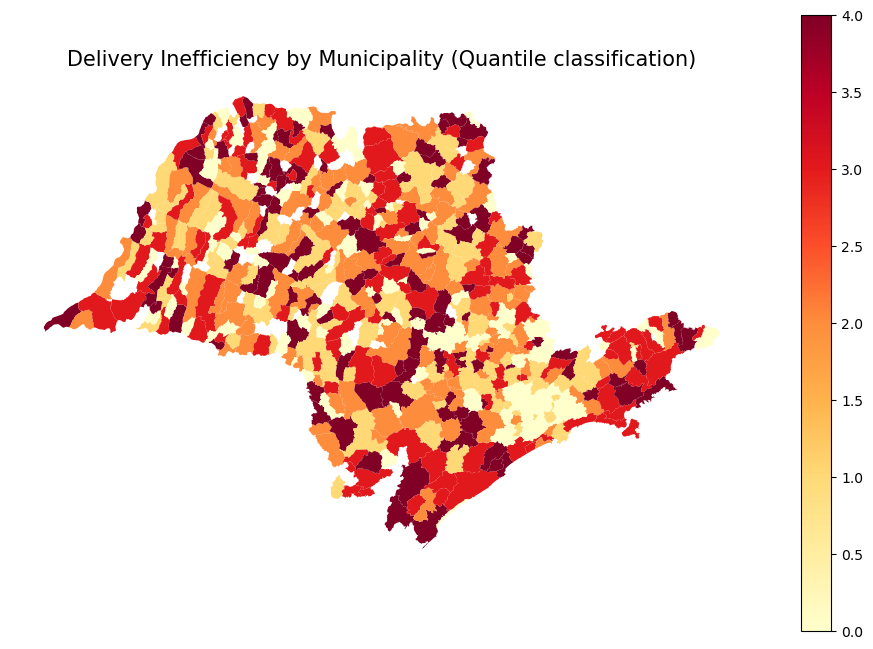

In [10]:
sp['delivery_rank'] = pd.qcut(sp['delivery_hours'], 
                                   q=5,
                                   labels= False)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# 2. Use 'quantiles' to ensure outliers don't dominate the color scale
# 'k=5' creates 5 equal-sized groups of municipalities
sp.plot(column='delivery_rank', 
              ax=ax, 
              legend=True, 
              # scheme='quantiles',  # Crucial for long-tail data
              # k=5, 
              cmap='YlOrRd', 
              # legend_kwds={'title': "Delivery Time Groups", 'loc': 'lower right'}
       )

ax.set_title('Delivery Inefficiency by Municipality (Quantile classification)', fontsize=15)
ax.axis('off')
plt.show()

#### Data Distribution (avg_delivery_hours)
`Box Plot` - Another long tail.

`Histogram` - Nearly bell shaped, most municipalities have less than 400 delivery hours.

I'll try to see which municipalites have those long delivery hours.

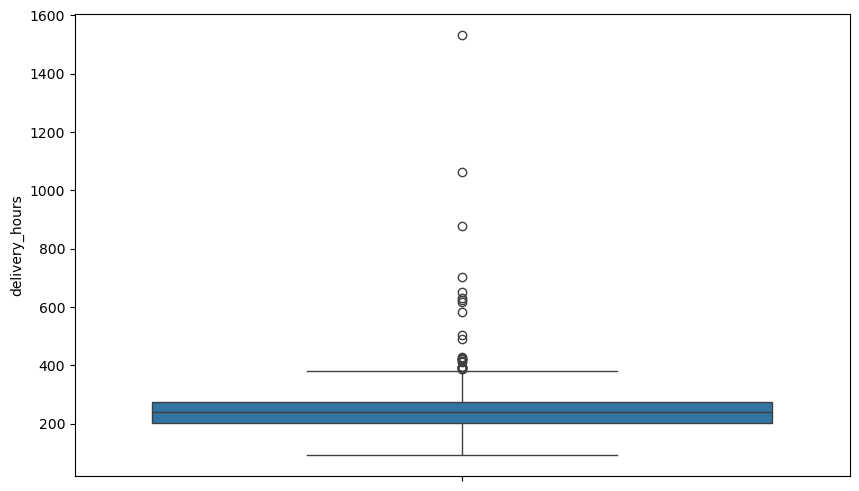

In [11]:
fig, ax = plt.subplots(figsize=(10, 6)) #

sns.boxplot(y='delivery_hours', data=sp, ax = ax)
plt.show()

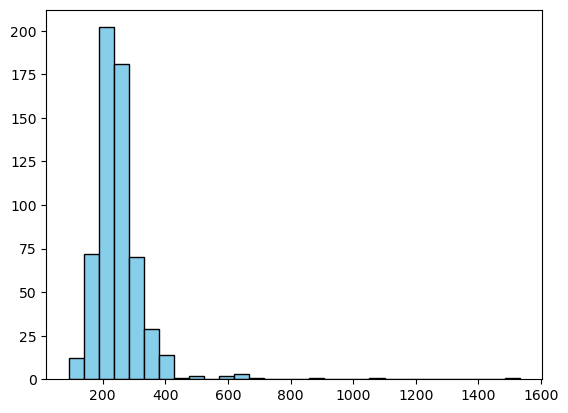

In [12]:
plt.hist(sp[['delivery_hours']] , bins=30, color='skyblue', edgecolor='black')
plt.show()

#### Scatter Plot
Check with a scatter plot to know that there is any realtion with total orders and average delivery hours.
They seems not related.

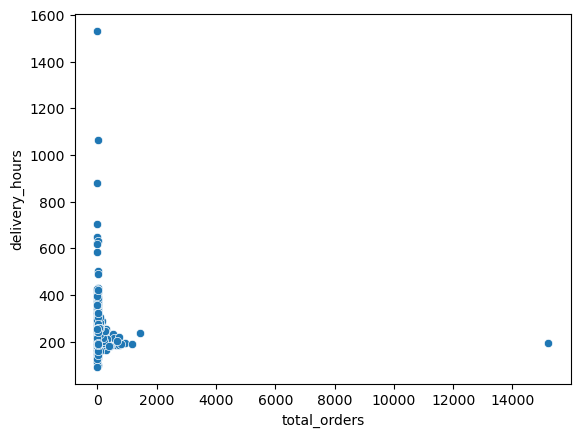

In [13]:
# Create a scatter plot
sns.scatterplot(data=sp, x="total_orders", y="delivery_hours")

# Display the plot
plt.show()

#### Delivery Inefficiency by Municipality 
Coloring municipalites which have longer than 400 dlivery hours.
I'll check the outlier municipalites on a map, to see it they are related by geolocation.

In [14]:
sp = sp.sort_values(by='total_orders', ascending=False)
sp.head(15)

,GEOCODIGO,NOME,UF,geometry,delivery_hours,delivery_days,total_orders,delivery_rank
553,3550308,São Paulo,SP,"POLYGON ((-46.77525 -23.76581, -46.77447 -23.7...",192.908680,8.037862,15211,0.0
501,3509502,Campinas,SP,"POLYGON ((-47.2448 -22.91013, -47.24273 -22.90...",235.318332,9.804930,1420,2.0
586,3518800,Guarulhos,SP,"POLYGON ((-46.53617 -23.36255, -46.53305 -23.3...",191.687085,7.986962,1154,0.0
576,3548708,São Bernardo do Campo,SP,"POLYGON ((-46.64824 -23.72961, -46.64694 -23.7...",193.531612,8.063817,926,0.0
585,3547809,Santo André,SP,"POLYGON ((-46.56578 -23.64853, -46.56341 -23.6...",188.337197,7.847383,783,0.0
558,3534401,Osasco,SP,"POLYGON ((-46.81739 -23.51983, -46.81522 -23.5...",184.253430,7.677226,736,0.0
596,3548500,Santos,SP,"POLYGON ((-46.32002 -23.80213, -46.31716 -23.8...",219.615613,9.150651,713,1.0
611,3549904,São José dos Campos,SP,"POLYGON ((-46.08171 -22.98497, -46.07761 -22.9...",203.867783,8.494491,675,1.0
458,3552205,Sorocaba,SP,"POLYGON ((-47.56428 -23.4676, -47.56364 -23.46...",187.403904,7.808496,612,0.0
531,3525904,Jundiaí,SP,"POLYGON ((-47.02805 -23.2359, -47.02686 -23.22...",214.691823,8.945493,557,1.0


In [15]:
Q3 = sp['delivery_hours'].quantile(0.75)
Q1 = sp['delivery_hours'].quantile(0.25)
IQR = Q3 - Q1

upper_bound = Q3 + IQR * 1.5
outliers = sp['delivery_hours'] > upper_bound

highlight = sp[outliers].copy()


In [16]:
# Center point for Nashville
sao_paulo = [-23.5558, -46.6396]

# Create map
m_sp = folium.Map(location=sao_paulo, zoom_start=6)

folium.Choropleth(
    geo_data=highlight,
    name='outlier municipalities',
    data=highlight,
    columns=['GEOCODIGO', 'delivery_days'],
    key_on='feature.properties.GEOCODIGO',
    fill_color= 'Reds',
    fill_opacity=0.8,
    line_opacity=1,
).add_to(m_sp)

# Create center column for the centroid of each district
# highlight['center'] = highlight.geometry.to_crs(epsg=3578).centroid.to_crs(epsg=4326)

# # Build markers and popups
# for row in highlight.iterrows():
#     row_values = row[1] 
#     center_point = row_values['center']
#     location = [center_point.y, center_point.x]
#     popup = ('Name: ' + str(row_values['NOME']) 
#              + ';  ' + 'waiting time: ' + str(row_values['delivery_hours'] / 24) 
#              + ';  ' + 'total orders: ' + str(row_values['total_orders'])
#     )
#     marker = folium.Marker(location = location, popup = popup)
#     marker.add_to(m)

# Add Marker to Mark Center Hub
marker = folium.Marker(location = sao_paulo)
marker.add_to(m_sp)

# Display the map
folium.LayerControl().add_to(m_sp)
display(m_sp)

In [17]:
highlight = highlight.sort_values(by='total_orders', ascending=False)
highlight[['NOME', 'total_orders']].head(10)

,NOME,total_orders
394,Barrinha,18
378,Ribeirão Bonito,7
117,Quintana,4
329,Barra do Turvo,4
563,São Sebastião da Grama,4
128,São João de Iracema,3
687,São José do Barreiro,3
446,Mombuca,3
427,Capela do Alto,3
334,Vista Alegre do Alto,3


### SP - Finding 
The busiest municipalities have the healthy delivery time.

The most slowest municipalities have very low number of total orders, they might not have seperte local hub for delivery.


### RJ

In [18]:
rj = transform(df, 'RJ')

rj.head()

,GEOCODIGO,NOME,UF,geometry,delivery_hours,delivery_days,total_orders
0,3303807,Parati,RJ,"POLYGON ((-44.88096 -23.21548, -44.88305 -23.2...",405.568409,16.898684,33
1,3304201,Resende,RJ,"POLYGON ((-44.80881 -22.4048, -44.80799 -22.40...",401.083480,16.711812,121
24,3300100,Angra dos Reis,RJ,"POLYGON ((-44.63307 -22.90495, -44.63191 -22.9...",396.401852,16.516744,87
26,3302254,Itatiaia,RJ,"POLYGON ((-44.66039 -22.37973, -44.65947 -22.3...",438.862719,18.285947,19
41,3304110,Porto Real,RJ,"POLYGON ((-44.3143 -22.4023, -44.31344 -22.402...",776.469206,32.352884,7


#### Data Distribution (avg_delivery_hours)
Box Plot - The mean delivery time is larger in RJ, but the sd is slightly smaller. No long tail.

The average delivery time in SP is better than in RJ. But, there are less suprise delay in RJ. 

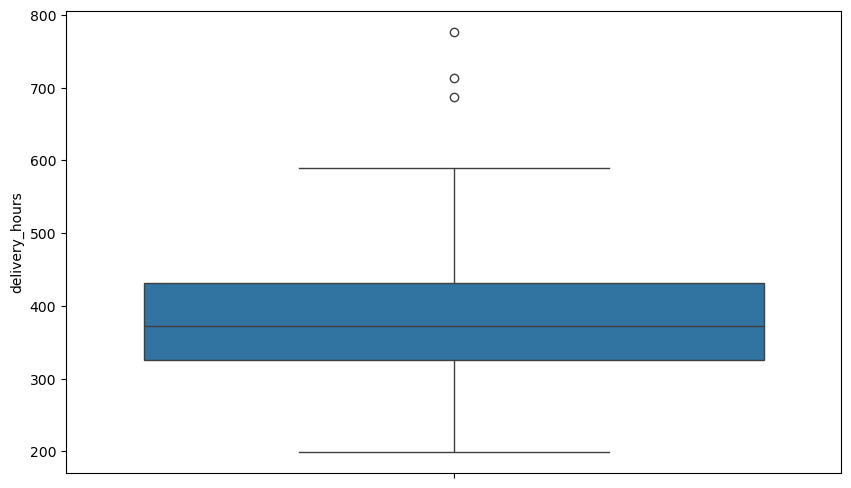

In [19]:
fig, ax = plt.subplots(figsize=(10, 6)) #

sns.boxplot(y='delivery_hours', data=rj, ax = ax)
plt.show()

In [20]:
rj.describe()

,delivery_hours,delivery_days,total_orders
count,92.000000,92.000000,92.000000
mean,385.177499,16.049062,135.510870
std,95.652102,3.985504,695.103368
min,198.990107,8.291254,1.000000
25%,326.060285,13.585845,11.500000
50%,371.849094,15.493712,23.500000
75%,431.635340,17.984806,61.250000
max,776.469206,32.352884,6640.000000


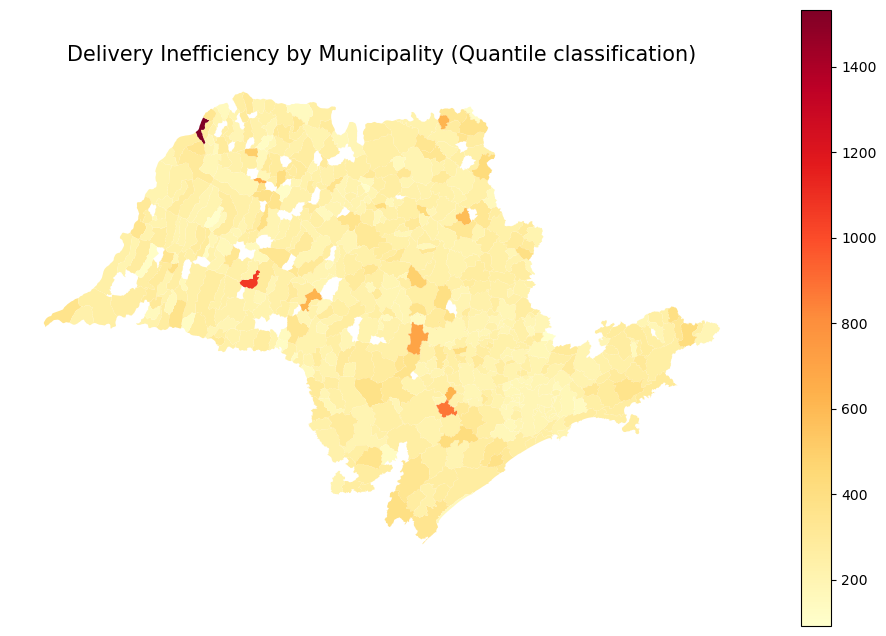

In [21]:
# sp['delivery_rank'] = pd.qcut(sp['delivery_hours'], 
#                                    q=5,
#                                    labels= False)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# 2. Use 'quantiles' to ensure outliers don't dominate the color scale
# 'k=5' creates 5 equal-sized groups of municipalities
sp.plot(column='delivery_hours', 
              ax=ax, 
              legend=True, 
              cmap='YlOrRd', 
       )

ax.set_title('Delivery Inefficiency by Municipality (Quantile classification)', fontsize=15)
ax.axis('off')
plt.show()

In [22]:
rj = rj.sort_values(by='delivery_hours', ascending = False)
rj.head(10)

,GEOCODIGO,NOME,UF,geometry,delivery_hours,delivery_days,total_orders
41,3304110,Porto Real,RJ,"POLYGON ((-44.3143 -22.4023, -44.31344 -22.402...",776.469206,32.352884,7
132,3301603,Duas Barras,RJ,"POLYGON ((-42.57207 -22.01863, -42.57204 -22.0...",713.311852,29.721327,3
142,3305901,Trajano de Morais,RJ,"POLYGON ((-42.29362 -22.1148, -42.29351 -22.11...",687.686424,28.653601,8
155,3300233,Armação dos Búzios,RJ,"POLYGON ((-41.97403 -22.7301, -41.97209 -22.72...",589.093393,24.545558,28
162,3306156,Varre-Sai,RJ,"POLYGON ((-41.91105 -20.92881, -41.90933 -20.9...",545.140139,22.714172,4
154,3300902,Cambuci,RJ,"POLYGON ((-42.11518 -21.60398, -42.11051 -21.6...",534.032639,22.251360,10
152,3302205,Itaperuna,RJ,"POLYGON ((-42.19548 -21.15956, -42.19268 -21.1...",499.781875,20.824245,52
137,3300258,Arraial do Cabo,RJ,"POLYGON ((-42.29104 -22.93906, -42.29095 -22.9...",495.683544,20.653481,29
82,3301801,Engenheiro Paulo de Frontin,RJ,"POLYGON ((-43.71676 -22.4957, -43.58382 -22.45...",475.903472,19.829311,6
130,3301207,Carmo,RJ,"POLYGON ((-42.66852 -21.87405, -42.66257 -21.8...",473.108773,19.712866,12


In [23]:
rj = rj.sort_values(by='total_orders', ascending = False)
rj.head()

,GEOCODIGO,NOME,UF,geometry,delivery_hours,delivery_days,total_orders
77,3304557,Rio de Janeiro,RJ,"POLYGON ((-43.79456 -22.91724, -43.79116 -22.9...",353.380467,14.724186,6640
114,3303302,Niterói,RJ,"POLYGON ((-43.12965 -22.90935, -43.12952 -22.9...",351.195705,14.633154,844
83,3303500,Nova Iguaçu,RJ,"POLYGON ((-43.67407 -22.86422, -43.67132 -22.8...",337.255593,14.052316,433
117,3304904,São Gonçalo,RJ,"POLYGON ((-43.10301 -22.85711, -43.10271 -22.8...",444.067745,18.502823,380
161,3301009,Campos dos Goytacazes,RJ,"POLYGON ((-41.88853 -21.86302, -41.88703 -21.8...",360.136447,15.005685,258


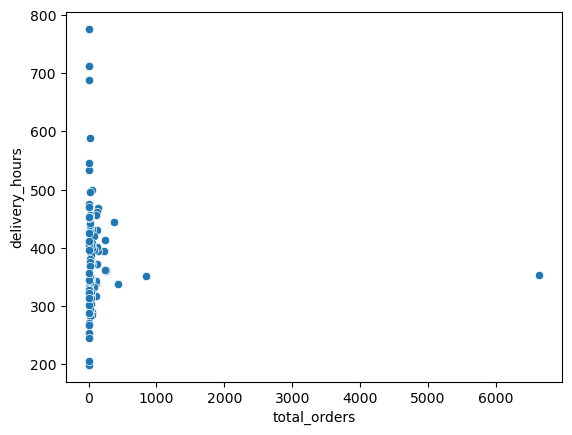

In [24]:
# Create a scatter plot
sns.scatterplot(data=rj, x="total_orders", y="delivery_hours")

# Display the plot
plt.show()

In [25]:
rj = rj.sort_values(by='delivery_hours', ascending = False)
highlight = rj.head(10).copy()

In [26]:
# Center point for Rio De JaNario
rio = [-22.9068,-43.1729]

# Create map
m_rj = folium.Map(location=rio, zoom_start=7)

folium.Choropleth(
    geo_data=highlight,
    name='outlier municipalities',
    data=highlight,
    columns=['GEOCODIGO', 'delivery_days'],
    key_on='feature.properties.GEOCODIGO',
    fill_color= 'Reds',
    fill_opacity=0.8,
    line_opacity=1,
).add_to(m_rj)

# # Create center column for the centroid of each district
# highlight['center'] = highlight.geometry.to_crs(epsg=3578).centroid.to_crs(epsg=4326)

# # Build markers and popups
# for row in highlight.iterrows():
#     row_values = row[1] 
#     center_point = row_values['center']
#     location = [center_point.y, center_point.x]
#     popup = ('Name: ' + str(row_values['NOME']) 
#              + ';  ' + 'waiting time: ' + str(row_values['delivery_hours'] / 24) 
#              + ';  ' + 'total orders: ' + str(row_values['total_orders'])
#     )
#     marker = folium.Marker(location = location, popup = popup)
#     marker.add_to(m)

# Add Marker to Mark Center Hub
marker = folium.Marker(location = rio)
marker.add_to(m_rj)

# Display the map
folium.LayerControl().add_to(m_rj)
display(m_rj)

In [28]:
highlight = highlight.sort_values(by='total_orders', ascending=False)
highlight[['NOME', 'total_orders']].head(10)

,NOME,total_orders
152,Itaperuna,52
137,Arraial do Cabo,29
155,Armação dos Búzios,28
130,Carmo,12
154,Cambuci,10
142,Trajano de Morais,8
41,Porto Real,7
82,Engenheiro Paulo de Frontin,6
162,Varre-Sai,4
132,Duas Barras,3


### RJ - Finding
The main municipality `Mangaratiba` have the largest number of total orders and have the most efficiency delivery hub.

As in SP, the suffering areas have low number of total orders. 
And, in most case in RJ, they are island, which might need special kind of transportation to get there.